<a href="https://colab.research.google.com/github/seelasairani7730-wq/Machine-Learning-Portfolio/blob/main/02_Logistic_Regression/Customer_Churn_Prediction/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction using Logistic Regression

## Project Overview

Customer churn is an important business problem where customers stop using a company's products or services.

In this project, Logistic Regression is used to predict whether a customer is likely to churn based on information such as tenure, contract type, monthly charges, payment method, internet service, and other customer attributes.

The project demonstrates a complete machine learning workflow, from data exploration and preprocessing to model training, prediction, and evaluation.

## Problem Statement

The objective of this project is to build a machine learning model that predicts whether a customer will:

- **Churn** — Customer leaves the service
- **Stay** — Customer continues using the service

The model can help businesses identify customers who may be at risk of leaving and support data-driven customer retention strategies.

## Machine Learning Algorithm

**Logistic Regression**

Logistic Regression is a supervised machine learning algorithm commonly used for binary classification problems.

In this project, the algorithm predicts the probability of a customer churning and classifies the customer into one of two classes: Churn or Stay.

## Project Workflow

1. Import required libraries
2. Load the dataset
3. Understand the dataset
4. Perform Exploratory Data Analysis (EDA)
5. Handle missing values
6. Analyze categorical and numerical features
7. Encode categorical variables
8. Split the dataset into training and testing sets
9. Train the Logistic Regression model
10. Make predictions
11. Evaluate model performance
12. Visualize the results
13. Analyze important factors related to churn
14. Save the trained model

In [61]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [62]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [63]:
df.shape

(7043, 21)

In [64]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

## Dataset Description

The dataset contains customer demographic information, subscribed services, contract details, billing information, and the customer's churn status.

### Feature Categories

**Customer Information**
- `customerID` — Unique identifier for each customer
- `gender` — Customer gender
- `SeniorCitizen` — Whether the customer is a senior citizen
- `Partner` — Whether the customer has a partner
- `Dependents` — Whether the customer has dependents

**Service Information**
- `PhoneService` — Whether phone service is subscribed
- `MultipleLines` — Whether multiple phone lines are subscribed
- `InternetService` — Type of internet service
- `OnlineSecurity` — Online security subscription
- `OnlineBackup` — Online backup subscription
- `DeviceProtection` — Device protection subscription
- `TechSupport` — Technical support subscription
- `StreamingTV` — Streaming TV subscription
- `StreamingMovies` — Streaming movie subscription

**Contract and Billing Information**
- `tenure` — Number of months the customer has stayed with the company
- `Contract` — Customer's contract type
- `PaperlessBilling` — Whether paperless billing is enabled
- `PaymentMethod` — Customer's payment method
- `MonthlyCharges` — Monthly amount charged to the customer
- `TotalCharges` — Total amount charged to the customer

**Target Variable**
- `Churn` — Whether the customer left the company

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [66]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [67]:
df["TotalCharges"].value_counts().head()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8


In [68]:
df["TotalCharges"].dtype

dtype('O')

In [69]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [70]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [71]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [72]:
df["TotalCharges"].dtype

dtype('float64')

In [73]:
df = df.dropna(subset=["TotalCharges"])

In [74]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [75]:
df.shape

(7032, 21)

## Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps us understand the distribution of the data, identify patterns, and discover relationships between customer characteristics and churn.

We will first analyze the target variable and then investigate how different customer features are related to churn.

In [76]:
df["Churn"].value_counts()

,count
Churn,
No,5163
Yes,1869


In [77]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.421502
Yes,26.578498


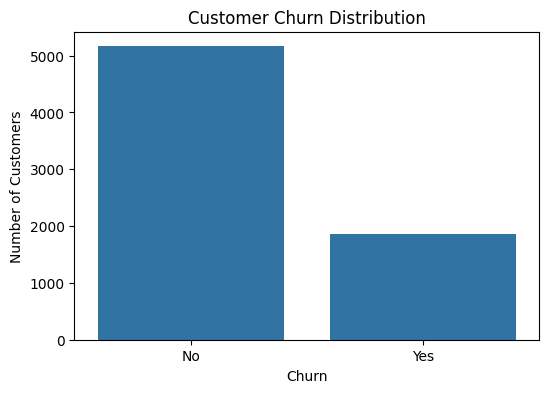

In [78]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

## Churn by Contract Type

Contract type is an important customer characteristic because customers may have different levels of commitment depending on whether they use a month-to-month, one-year, or two-year contract.

We will compare churn across different contract types to identify potential patterns in customer retention.

In [79]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [80]:
churn_by_contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

churn_by_contract

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


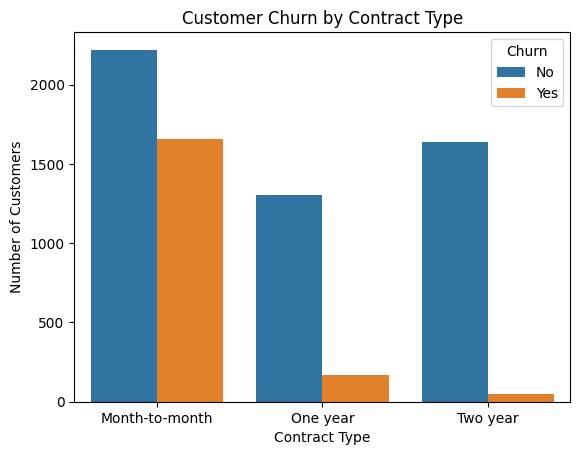

In [81]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

## Tenure and Customer Churn

Tenure represents the number of months a customer has remained with the company.

Analyzing tenure can help us understand whether customers with shorter or longer relationships with the company show different churn patterns.

In [82]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


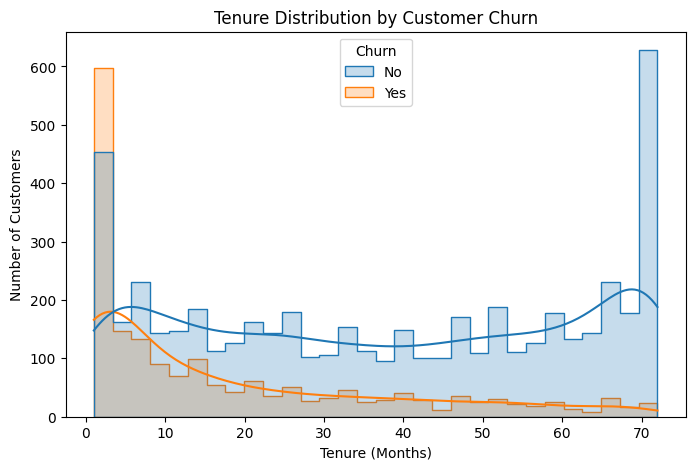

In [83]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Tenure Distribution by Customer Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

## Monthly Charges and Customer Churn

MonthlyCharges represents the amount billed to a customer each month.

We will compare monthly charges between customers who stayed and customers who churned to identify whether there are differences in their billing patterns.

In [84]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


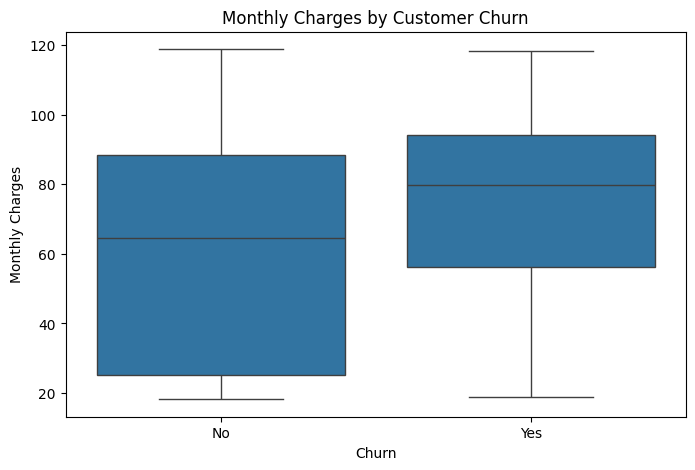

In [85]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

## Payment Method and Customer Churn

Payment method describes how customers pay for their services.

We will compare churn rates across payment methods to identify whether customer churn varies between different payment options.

In [86]:
churn_by_payment = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

churn_by_payment

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


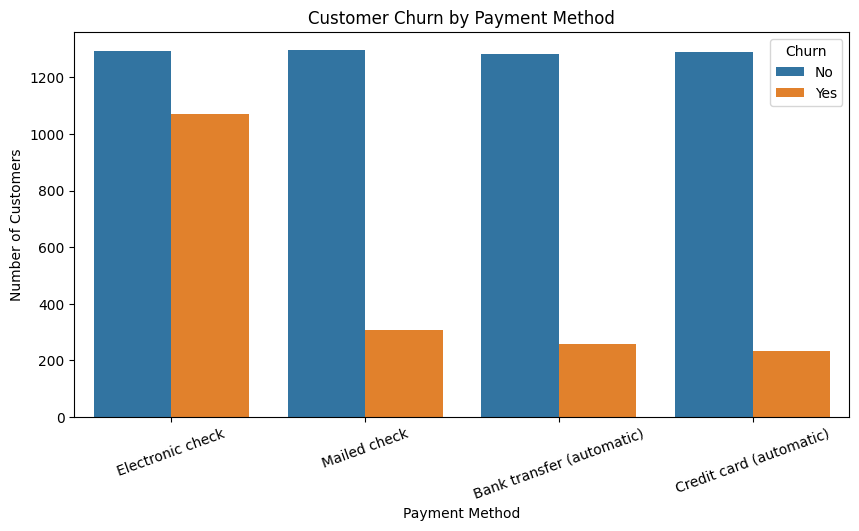

In [87]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

## Correlation Analysis

Correlation analysis helps us understand the relationships between numerical features.

We will examine the numerical variables to identify relationships that may be useful for understanding the dataset and preparing the features for modeling.

In [88]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

correlation_matrix = df[numeric_features].corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


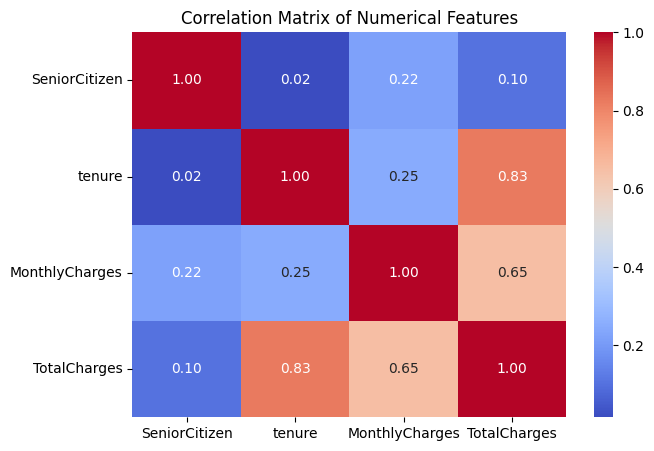

In [89]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

## Data Preprocessing

Before training the Logistic Regression model, the dataset needs to be transformed into a suitable format.

The preprocessing steps include removing unnecessary identifiers, separating the target variable from the input features, encoding categorical variables, and scaling numerical features.


In [90]:
# Remove customerID because it is only a unique identifier
df = df.drop(columns=["customerID"])

# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7032, 19)
Target shape: (7032,)


In [91]:
y.head()

,Churn
0,0
1,0
2,1
3,0
4,1


## Identifying Numerical and Categorical Features

Machine learning models require numerical input, but the dataset contains both numerical and categorical features.

We will separate these features so that numerical variables can be scaled and categorical variables can be converted into numerical representations using one-hot encoding.


In [92]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Train-Test Split

The dataset is divided into training and testing sets before preprocessing.

* **80% of the data** is used to train the model.
* **20% of the data** is reserved for evaluating the model.
* Stratification is used to maintain a similar proportion of churned and non-churned customers in both sets.

The split is performed before scaling to prevent data leakage from the test set.


In [93]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 19)
X_test : (1407, 19)
y_train: (5625,)
y_test : (1407,)


## Feature Encoding and Scaling

The dataset contains both numerical and categorical features, so different preprocessing techniques are required.

* Numerical features are standardized using **StandardScaler**.
* Categorical features are converted into numerical features using **OneHotEncoder**.
* A **ColumnTransformer** is used to apply the appropriate preprocessing to each group of features.

This preprocessing is fitted only on the training data to prevent data leakage.


In [94]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [95]:
# Preprocessing for numerical and categorical features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

In [96]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (5625, 30)
Processed X_test shape: (1407, 30)


In [97]:
preprocessor.fit_transform(X_train)

array([[-0.43931886,  1.3218163 ,  0.98155578, ...,  1.        ,
         0.        ,  0.        ],
       [-0.43931886, -0.26741023, -0.97154551, ...,  0.        ,
         1.        ,  0.        ],
       [-0.43931886,  1.4440645 ,  0.83706615, ...,  1.        ,
         0.        ,  0.        ],
       ...,
       [-0.43931886,  0.14008375,  0.92674937, ...,  1.        ,
         0.        ,  0.        ],
       [-0.43931886, -0.9194006 ,  0.02991714, ...,  0.        ,
         0.        ,  1.        ],
       [ 2.27625101, -1.28614519,  0.32221802, ...,  0.        ,
         1.        ,  0.        ]])

In [98]:
preprocessor.transform(X_test)

array([[-0.43931886,  1.07731992,  0.36373803, ...,  1.        ,
         0.        ,  0.        ],
       [-0.43931886, -1.0416488 ,  0.45009965, ...,  0.        ,
         0.        ,  0.        ],
       [-0.43931886,  0.87357292, -1.49137604, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.43931886, -1.20464639, -1.51296645, ...,  0.        ,
         0.        ,  1.        ],
       [-0.43931886,  0.18083315, -0.81210867, ...,  0.        ,
         0.        ,  1.        ],
       [-0.43931886,  0.71057533, -1.48971524, ...,  1.        ,
         0.        ,  0.        ]])

In [99]:
print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Processed X_train shape: (5625, 30)
Processed X_test shape: (1407, 30)


## Logistic Regression Model Training

After preprocessing the dataset, the transformed training data is used to train a Logistic Regression model.

Logistic Regression is suitable for this problem because the target variable contains two possible outcomes:

* **0 → Customer stays**
* **1 → Customer churns**

The model learns the relationship between customer characteristics and the probability of churn.


In [100]:
# Create the Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


## Making Predictions

The trained Logistic Regression model is used to make predictions on the unseen test dataset.

Two types of predictions are generated:

* **Class predictions** — whether the customer is predicted to stay or churn.
* **Probability predictions** — the estimated probability of each outcome.


In [101]:
# Predict the class for test data
y_pred = logistic_model.predict(X_test_processed)

# Predict churn probabilities
y_prob = logistic_model.predict_proba(X_test_processed)[:, 1]

print("First 10 predicted classes:")
print(y_pred[:10])

print("\nFirst 10 churn probabilities:")
print(y_prob[:10])

First 10 predicted classes:
[0 1 0 0 0 0 0 0 1 0]

First 10 churn probabilities:
[0.01802218 0.59183207 0.00489153 0.20142434 0.10376232 0.47052094
 0.02638963 0.16510364 0.67642949 0.01571737]


## Model Evaluation

The Logistic Regression model is evaluated using the predictions made on the unseen test dataset.

The evaluation includes:

* **Accuracy** — proportion of all predictions that are correct.
* **Confusion Matrix** — shows the number of correct and incorrect predictions for each class.
* **Precision** — measures how many customers predicted as churners actually churned.
* **Recall** — measures how many actual churners were correctly identified.
* **F1-score** — provides a balance between precision and recall.


In [102]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8052594171997157
Accuracy (%): 80.52594171997157


In [103]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[918 115]
 [159 215]]


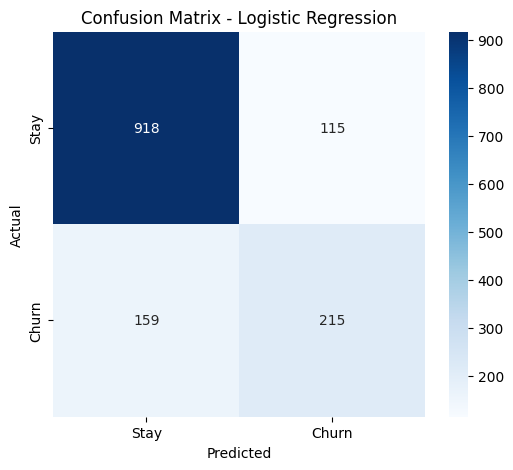

In [104]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stay", "Churn"],
    yticklabels=["Stay", "Churn"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [105]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stay", "Churn"]
))

              precision    recall  f1-score   support

        Stay       0.85      0.89      0.87      1033
       Churn       0.65      0.57      0.61       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



In [106]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.8360739966143986


## ROC-AUC Evaluation

The Logistic Regression model achieved a **ROC-AUC score of 0.8361**.

ROC-AUC evaluates the model's ability to distinguish between customers who churn and customers who stay across different classification thresholds.

The result indicates that the model has a useful ability to separate the two classes and provides a stronger evaluation of the classifier than accuracy alone.


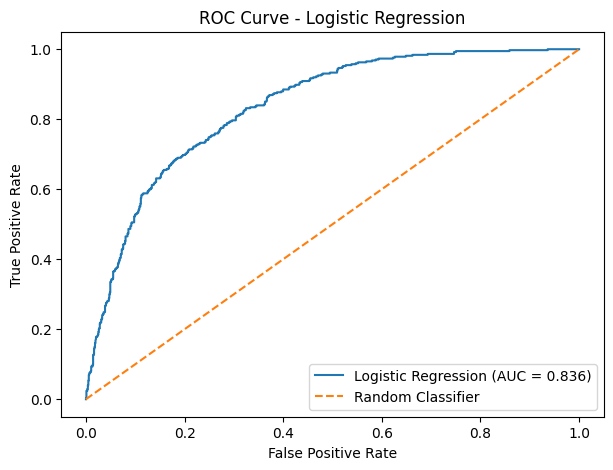

In [107]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [108]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 30
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Male' 'cat__Partner_Yes'
 'cat__Dependents_Yes' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No internet service' 'cat__OnlineSecurity_Yes'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No internet service' 'cat__DeviceProtection_Yes'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes'
 'cat__StreamingTV_No internet service' 'cat__StreamingTV_Yes'
 'cat__StreamingMovies_No internet service' 'cat__StreamingMovies_Yes'
 'cat__Contract_One year' 'cat__Contract_Two year'
 'cat__PaperlessBilling_Yes' 'cat__PaymentMethod_Credit card (automatic)'
 'cat__PaymentMethod_Electronic check' 'cat__PaymentMethod_Mailed check']


In [109]:
coefficients = logistic_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(10)

,Feature,Coefficient,Absolute_Coefficient
25,cat__Contract_Two year,-1.364823,1.364823
1,num__tenure,-1.357404,1.357404
10,cat__InternetService_Fiber optic,1.107407,1.107407
24,cat__Contract_One year,-0.750068,0.750068
3,num__TotalCharges,0.645508,0.645508
7,cat__PhoneService_Yes,-0.515337,0.515337
2,num__MonthlyCharges,-0.434497,0.434497
28,cat__PaymentMethod_Electronic check,0.379150,0.379150
13,cat__OnlineSecurity_Yes,-0.373187,0.373187
21,cat__StreamingTV_Yes,0.372407,0.372407


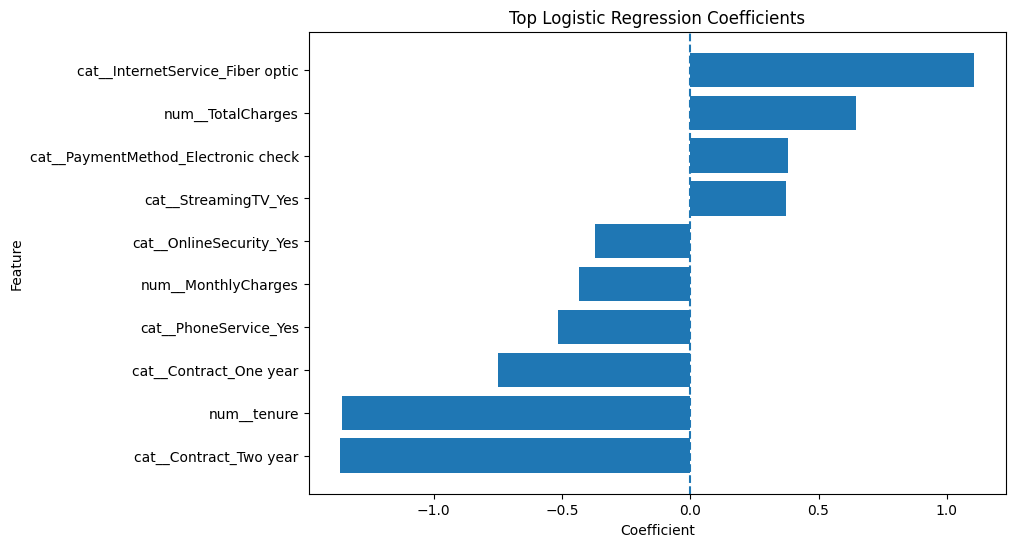

In [110]:
top_features = feature_importance.head(10).sort_values(
    "Coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.title("Top Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

## Saving the Model

The preprocessing steps and Logistic Regression model are combined into a single pipeline.

Saving the complete pipeline ensures that new customer data can be passed through the same preprocessing steps before generating predictions.

The trained pipeline can therefore be reused without manually repeating the encoding and scaling process.


In [111]:
from sklearn.pipeline import Pipeline
import joblib

In [112]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [113]:
model_pipeline.fit(X_train, y_train)

print("Complete pipeline trained successfully!")

Complete pipeline trained successfully!


In [114]:
joblib.dump(
    model_pipeline,
    "customer_churn_logistic_regression.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [115]:
import os

print(os.path.exists("customer_churn_logistic_regression.pkl"))

True


In [116]:
# Load the saved pipeline
loaded_model = joblib.load("customer_churn_logistic_regression.pkl")

# Make predictions using the raw test data
loaded_pred = loaded_model.predict(X_test)

# Compare with the original predictions
print("Predictions match:", np.array_equal(y_pred, loaded_pred))

# Compare predicted probabilities
loaded_prob = loaded_model.predict_proba(X_test)[:, 1]

print("Probabilities match:", np.allclose(y_prob, loaded_prob))

Predictions match: True
Probabilities match: True


In [117]:
import os

os.makedirs("images", exist_ok=True)

print("images folder created!")

images folder created!


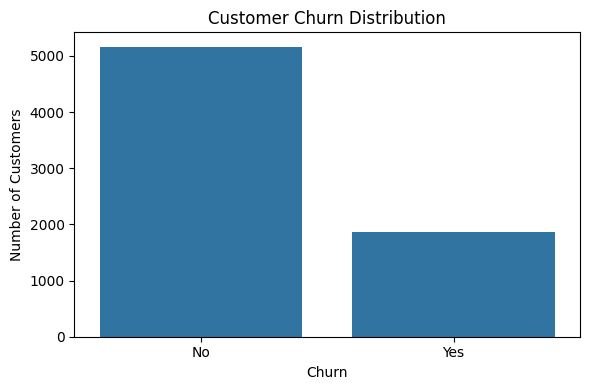

In [118]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("images/churn_distribution.png", dpi=300)
plt.show()

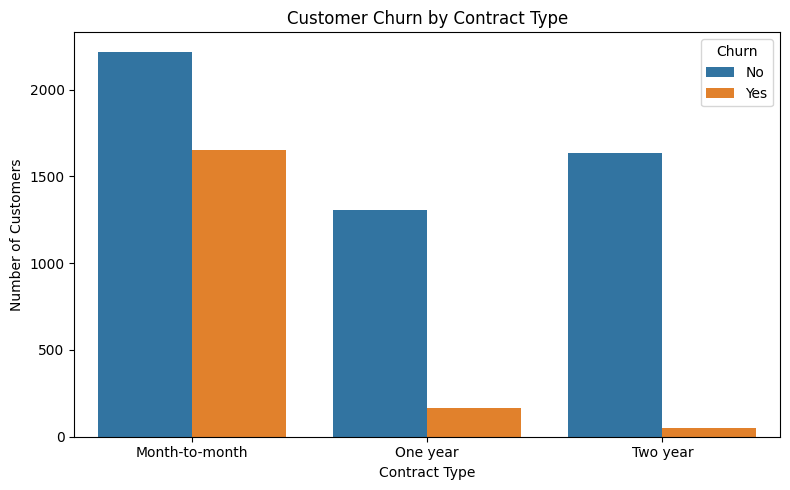

In [119]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.savefig("images/contract_churn.png", dpi=300)
plt.show()